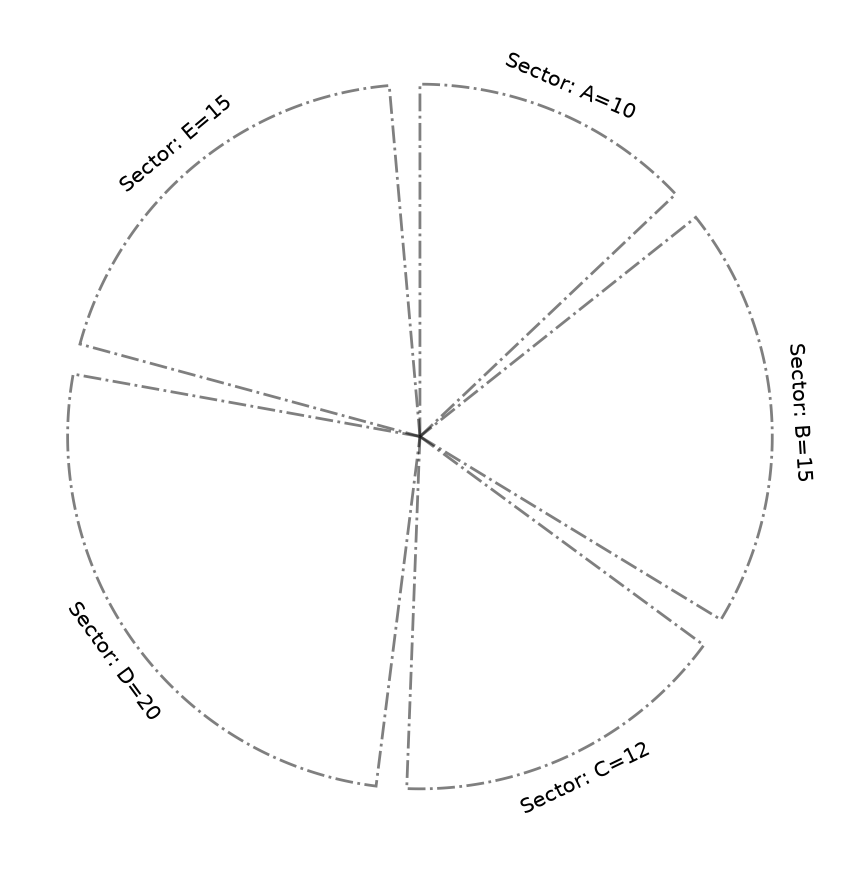

In [1]:
from pycirclize import Circos

# 初始化 circos 扇区：扇区名词以及扇区大小（所占角度比例）
sectors = {"A": 10, "B": 15, "C": 12, "D": 20, "E": 15}
circos = Circos(sectors, space=5)  # 扇区之间的间隔为 5°

#  遍历每个扇区
for sector in circos.sectors:
    # 绘制扇区的坐标轴和文本
    sector.axis(fc="none", ls="dashdot", lw=2, ec="black", alpha=0.5)
    sector.text(f"Sector: {sector.name}={sector.size}", size=15)

fig = circos.plotfig()

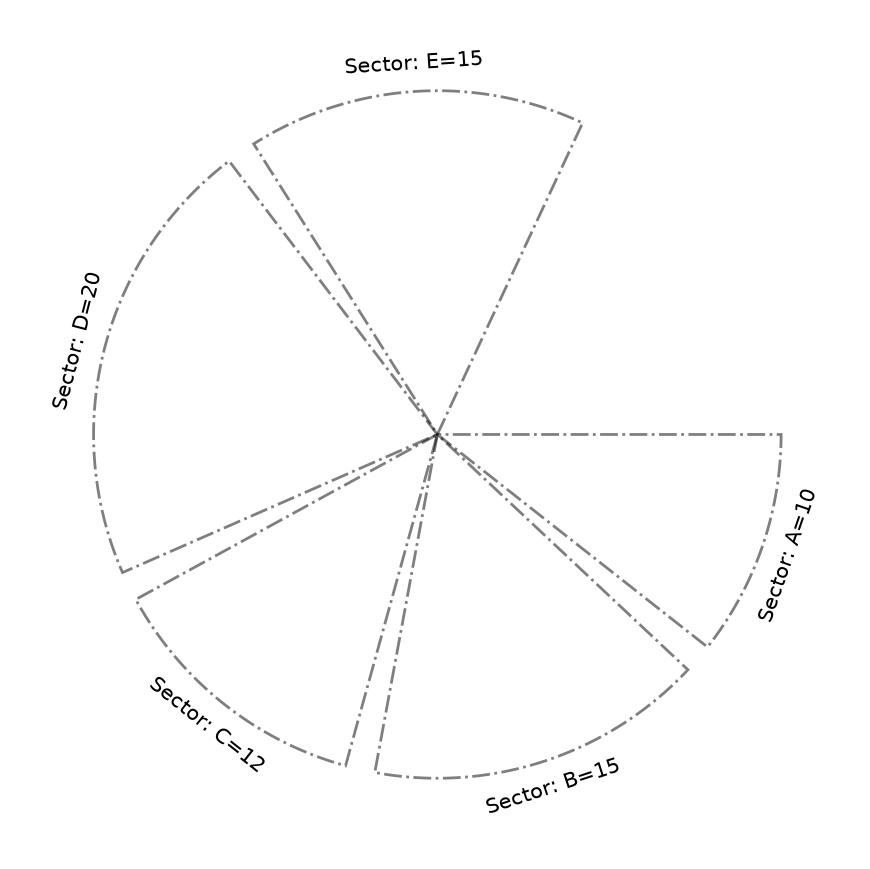

In [2]:
from pycirclize import Circos

# Initialize circos sectors
sectors = {"A": 10, "B": 15, "C": 12, "D": 20, "E": 15}
circos = Circos(sectors, space=5, start=-270, end=30)  # Set start-end degree ranges

for sector in circos.sectors:
    # Plot sector axis & name text
    sector.axis(fc="none", ls="dashdot", lw=2, ec="black", alpha=0.5)
    sector.text(f"Sector: {sector.name}={sector.size}", size=15)

fig = circos.plotfig()

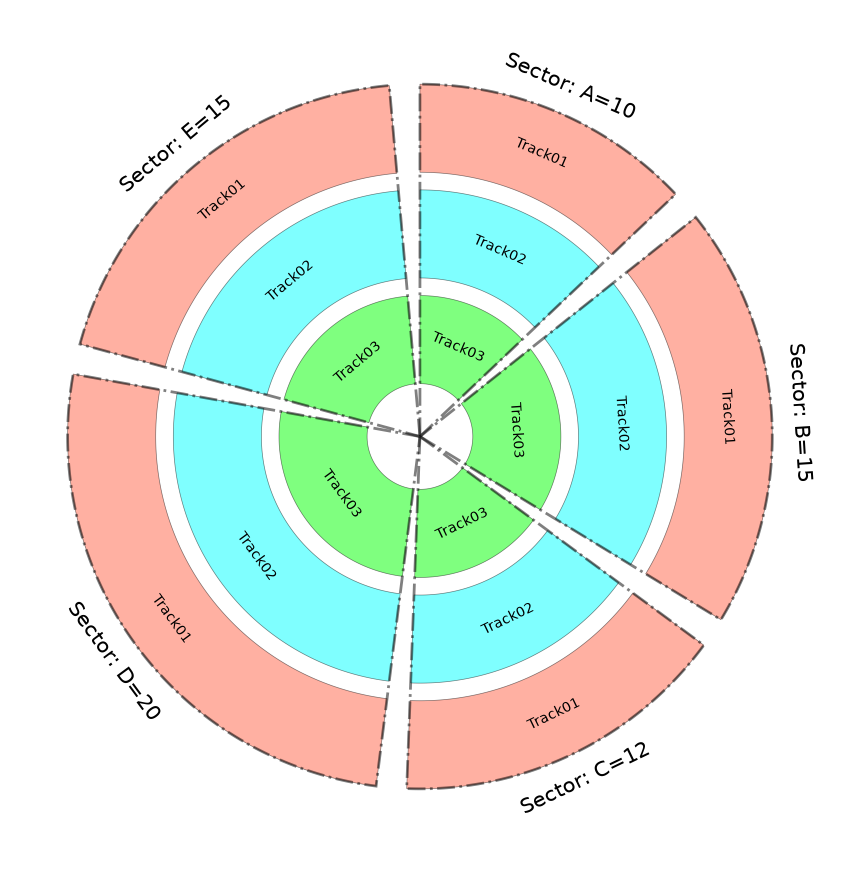

In [3]:
from pycirclize import Circos

# Initialize circos sectors
sectors = {"A": 10, "B": 15, "C": 12, "D": 20, "E": 15}
circos = Circos(sectors, space=5)

for sector in circos.sectors:
    # Plot sector axis & name text
    sector.axis(fc="none", ls="dashdot", lw=2, ec="black", alpha=0.5)
    sector.text(f"Sector: {sector.name}={sector.size}", size=15)
    # Set Track01 (Radius: 75 - 100)
    track1 = sector.add_track((75, 100))
    track1.axis(fc="tomato", alpha=0.5)
    track1.text(track1.name)
    # Set Track02 (Radius: 45 - 70)
    track2 = sector.add_track((45, 70))
    track2.axis(fc="cyan", alpha=0.5)
    track2.text(track2.name)
    # Set Track03 (Radius: 15 - 40)
    track3 = sector.add_track((15, 40))
    track3.axis(fc="lime", alpha=0.5)
    track3.text(track3.name)

fig = circos.plotfig()

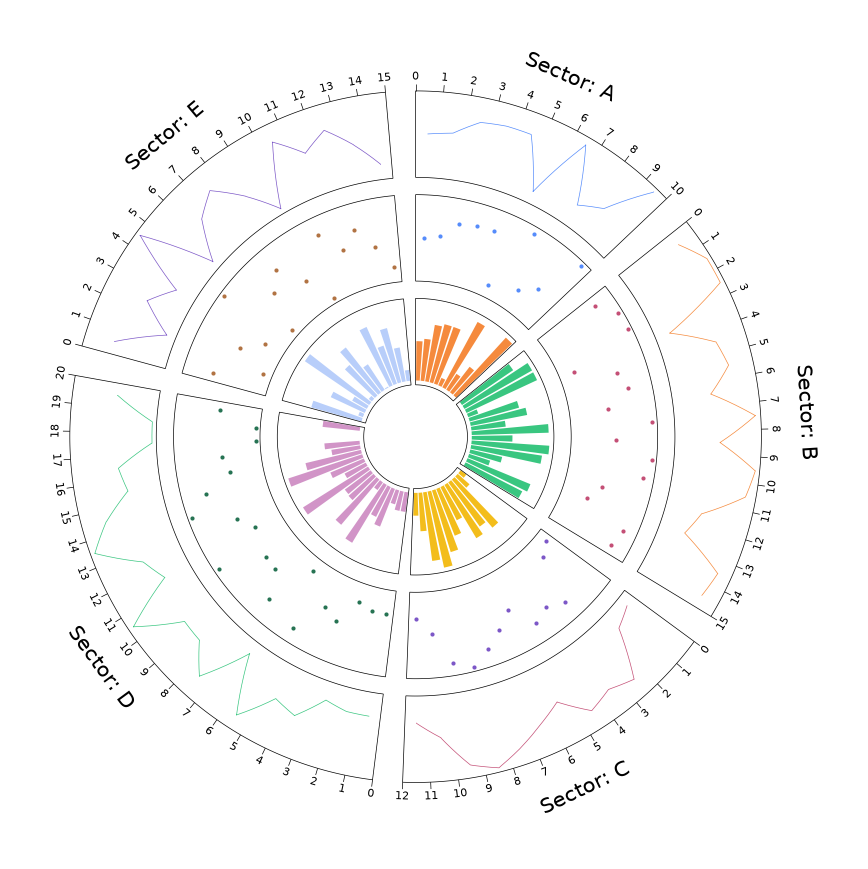

In [4]:
from pycirclize import Circos
import numpy as np

np.random.seed(0)

sectors = {"A": 10, "B": 15, "C": 12, "D": 20, "E": 15}
circos = Circos(sectors, space=5)
for sector in circos.sectors:
    # 设置扇区名词 r=110 代表文本距离圆心的半径，size=15 为字体大小
    sector.text(f"Sector: {sector.name}", r=110, size=15)
    # 为数据绘图创建 x 轴位置（从扇区起点到终点）及随机生成的 y 轴数值
    x = np.arange(sector.start, sector.end) + 0.5
    y = np.random.randint(0, 100, len(x))
    # 绘制折线图 (Line)
    # 添加一个轨道，半径范围为 75 到 100，轨道间距比例为 0.1
    line_track = sector.add_track((75, 100), r_pad_ratio=0.1)
    line_track.axis() # 绘制轨道轴线
    line_track.xticks_by_interval(1) # 设置 X 轴刻度间隔为 1
    line_track.line(x, y) # 在轨道上绘制折线图
    # 绘制散点图 (Points)
    # 添加第二个轨道，半径范围为 45 到 70
    points_track = sector.add_track((45, 70), r_pad_ratio=0.1)
    points_track.axis() # 绘制轨道轴线
    points_track.scatter(x, y) # 在轨道上绘制散点图
    # 绘制柱状图 (Bar)
    # 添加第三个轨道，半径范围为 15 到 40
    bar_track = sector.add_track((15, 40), r_pad_ratio=0.1)
    bar_track.axis()
    bar_track.bar(x, y)

fig = circos.plotfig()

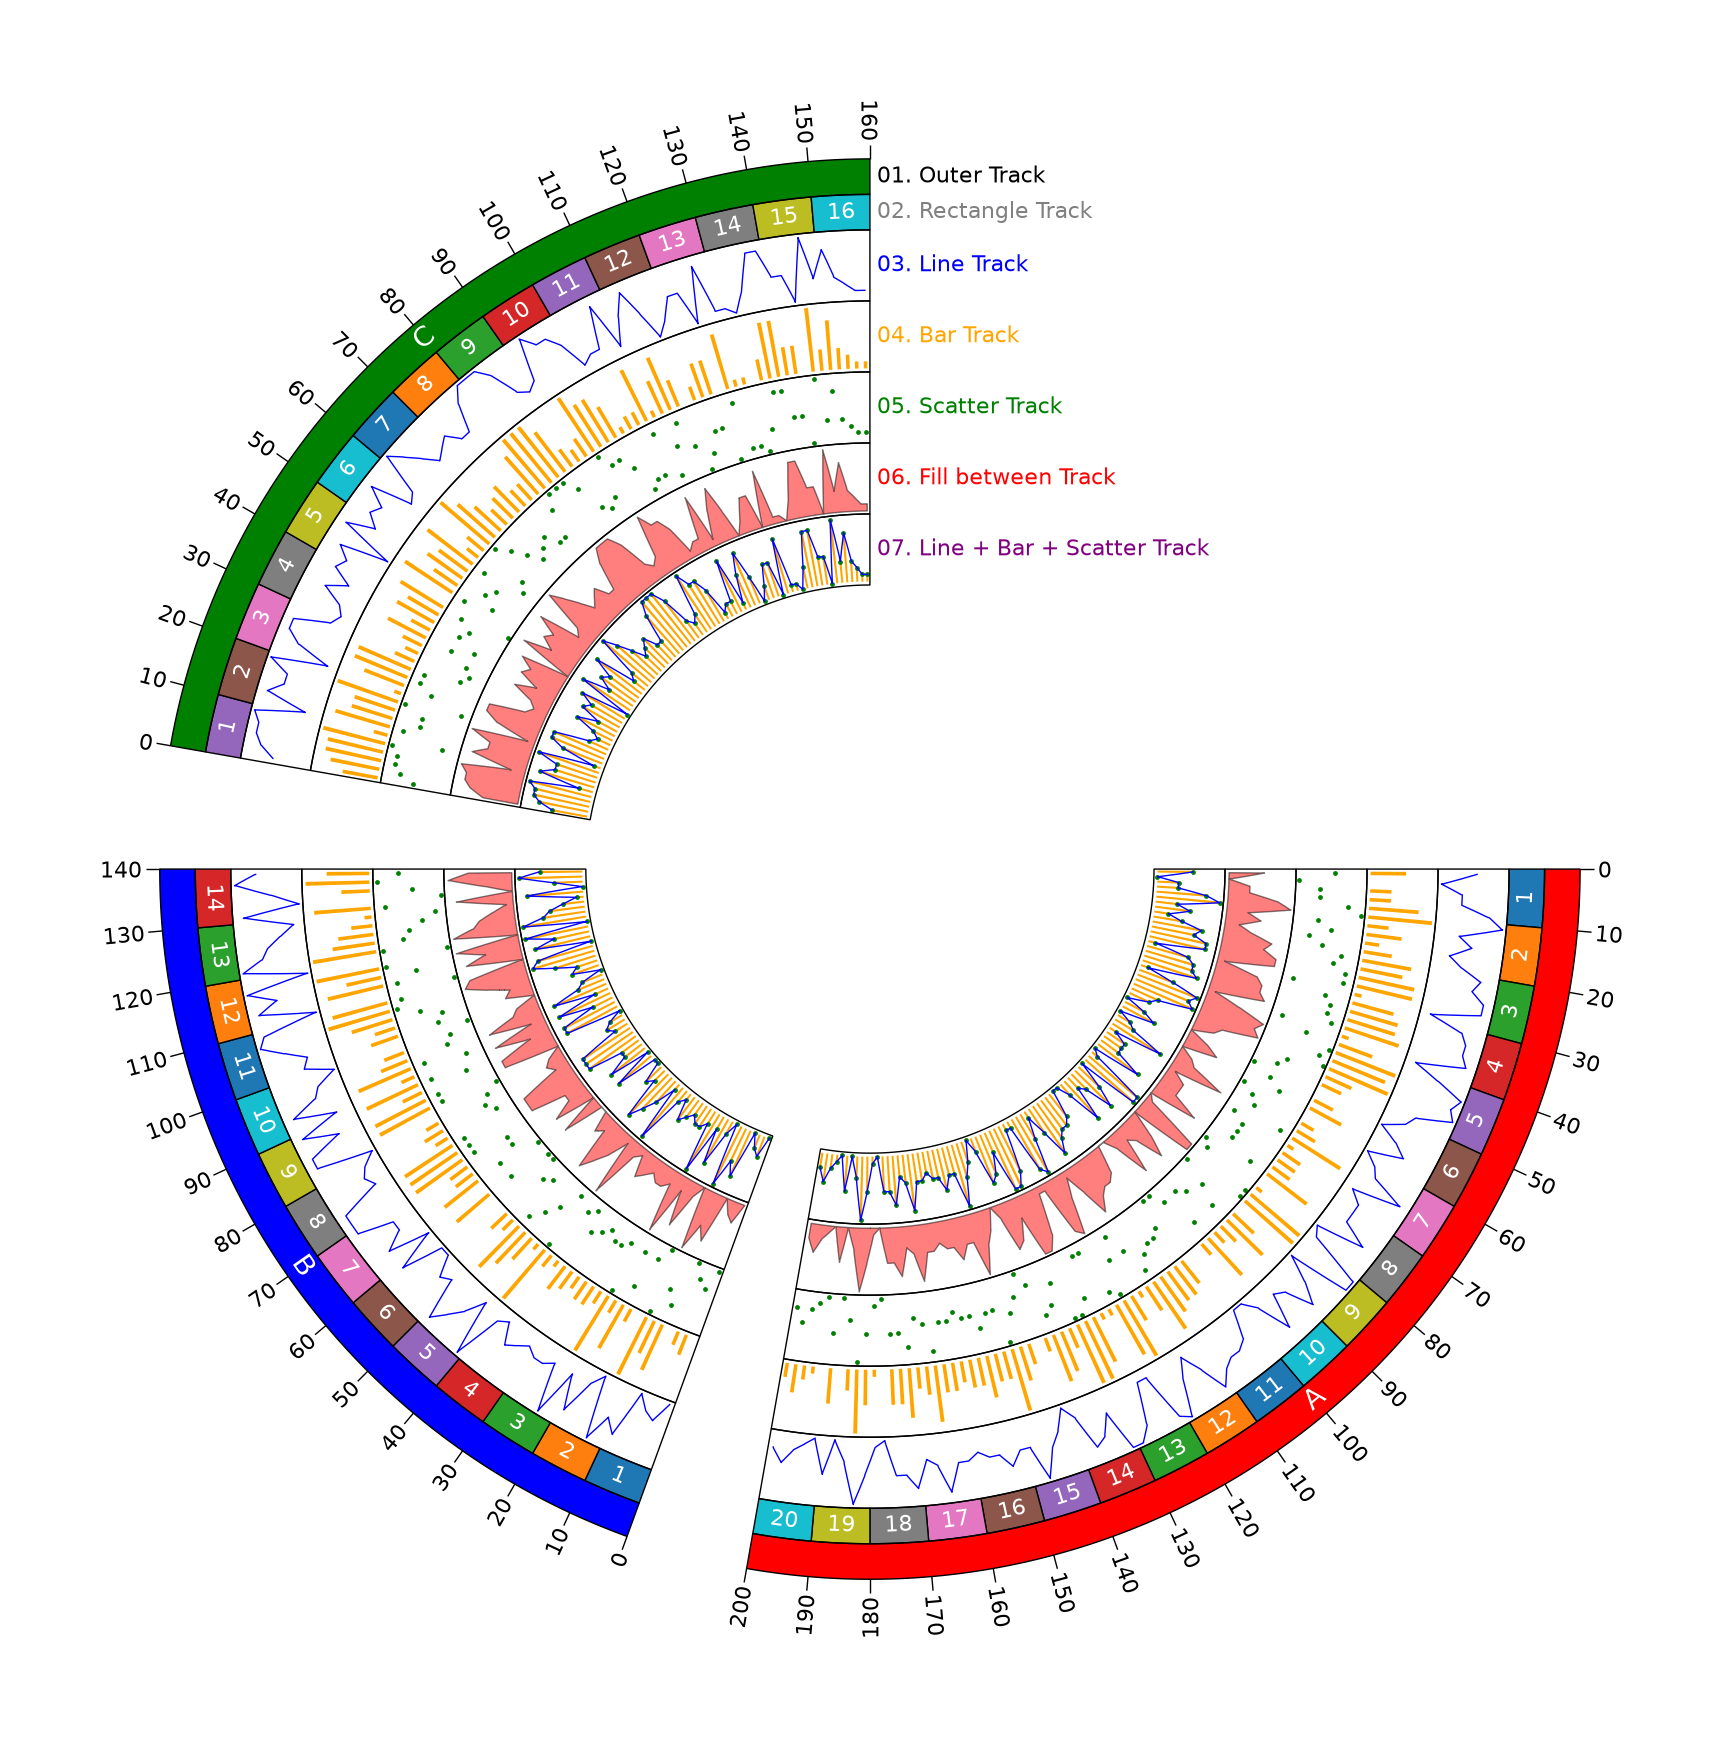

In [6]:
%config InlineBackend.figure_format = 'retina'
from pycirclize import Circos
from pycirclize.utils import ColorCycler
import numpy as np

np.random.seed(0)
# 设置颜色循环器使用的调色板为 "tab10"
ColorCycler.set_cmap("tab10")

# 定义各个扇区（sectors）的名称及其大小
sectors = {"A": 200, "B": 140, "C": 160}
# 为每个扇区指定专属颜色
sector_colors = {"A": "red", "B": "blue", "C": "green"}
# 创建 Circos 对象，设置扇区间隔为 10，起始角度为 90 度，结束角度为 360 度，且末尾不留空白
circos = Circos(sectors, space=10, start=90, end=360, endspace=False)

# 遍历 Circos 对象中的每一个扇区
for sector in circos.sectors:
    # === 1. 外部轨道 (Outer Track) ===
    outer_track = sector.add_track((95, 100))
    outer_track.text(sector.name, color="white") # 在轨道上显示扇区名称
    outer_track.axis(fc=sector_colors[sector.name]) # 绘制轨道轴线，填充色为扇区专属颜色
    outer_track.xticks_by_interval(interval=10, label_orientation="vertical") # 设置刻度间隔为 10，标签垂直显示

    # === 2. 矩形轨道 (Rectangle Track) ===
    rect_track = sector.add_track((90, 95))
    rect_size = 10 # 每个矩形的宽度
    # 循环绘制矩形块
    for i in range(int(rect_track.size / rect_size)):
        x1, x2 = i * rect_size, i * rect_size + rect_size
         # 绘制矩形，设置边框为黑色、线宽 0.5，颜色由 ColorCycler 自动分配
        rect_track.rect(x1, x2, ec="black", lw=0.5, color=ColorCycler())
         # 绘制矩形，设置边框为黑色、线宽 0.5，颜色由 ColorCycler 自动分配
        rect_track.text(str(i + 1), (x1 + x2) / 2, size=8, color="white")

    # === 准备绘图数据 ===
    # 生成随机 x, y 绘图数据（x 为从 1 到扇区大小的奇数序列，y 为 0-9 的随机整数）
    x = np.arange(1, int(sector.size), 2)
    y = np.random.randint(0, 10, len(x))

    # === 3. 折线轨道 (Line Track) ===
    line_track = sector.add_track((80, 90), r_pad_ratio=0.1)
    line_track.axis()
    line_track.line(x, y, color="blue")
    # Scatter Track
    scatter_track = sector.add_track((70, 80), r_pad_ratio=0.1)
    scatter_track.axis()
    scatter_track.bar(x, y, width=0.8, color="orange")
    # Bar Track
    bar_track = sector.add_track((60, 70), r_pad_ratio=0.1)
    bar_track.axis()
    bar_track.scatter(x, y, color="green", s=3)
    # Fill Track
    fill_track = sector.add_track((50, 60), r_pad_ratio=0.1)
    fill_track.axis()
    fill_track.fill_between(x, y, y2=0, fc="red", ec="black", lw=0.5, alpha=0.5)
    # Line + Bar + Scatter Track
    line_bar_scatter_track = sector.add_track((40, 50), r_pad_ratio=0.1)
    line_bar_scatter_track.axis()
    line_bar_scatter_track.line(x, y, color="blue")
    line_bar_scatter_track.bar(x, y, width=0.8, color="orange")
    line_bar_scatter_track.scatter(x, y, color="green", s=3)

# Plot text description
text_common_kws = dict(ha="left", va="center", size=8)
circos.text(" 01. Outer Track", r=97.5, color="black", **text_common_kws)
circos.text(" 02. Rectangle Track", r=92.5, color="grey", **text_common_kws)
circos.text(" 03. Line Track", r=85, color="blue", **text_common_kws)
circos.text(" 04. Bar Track", r=75, color="orange", **text_common_kws)
circos.text(" 05. Scatter Track", r=65, color="green", **text_common_kws)
circos.text(" 06. Fill between Track", r=55, color="red", **text_common_kws)
circos.text(" 07. Line + Bar + Scatter Track", r=45, color="purple", **text_common_kws)

fig = circos.plotfig()

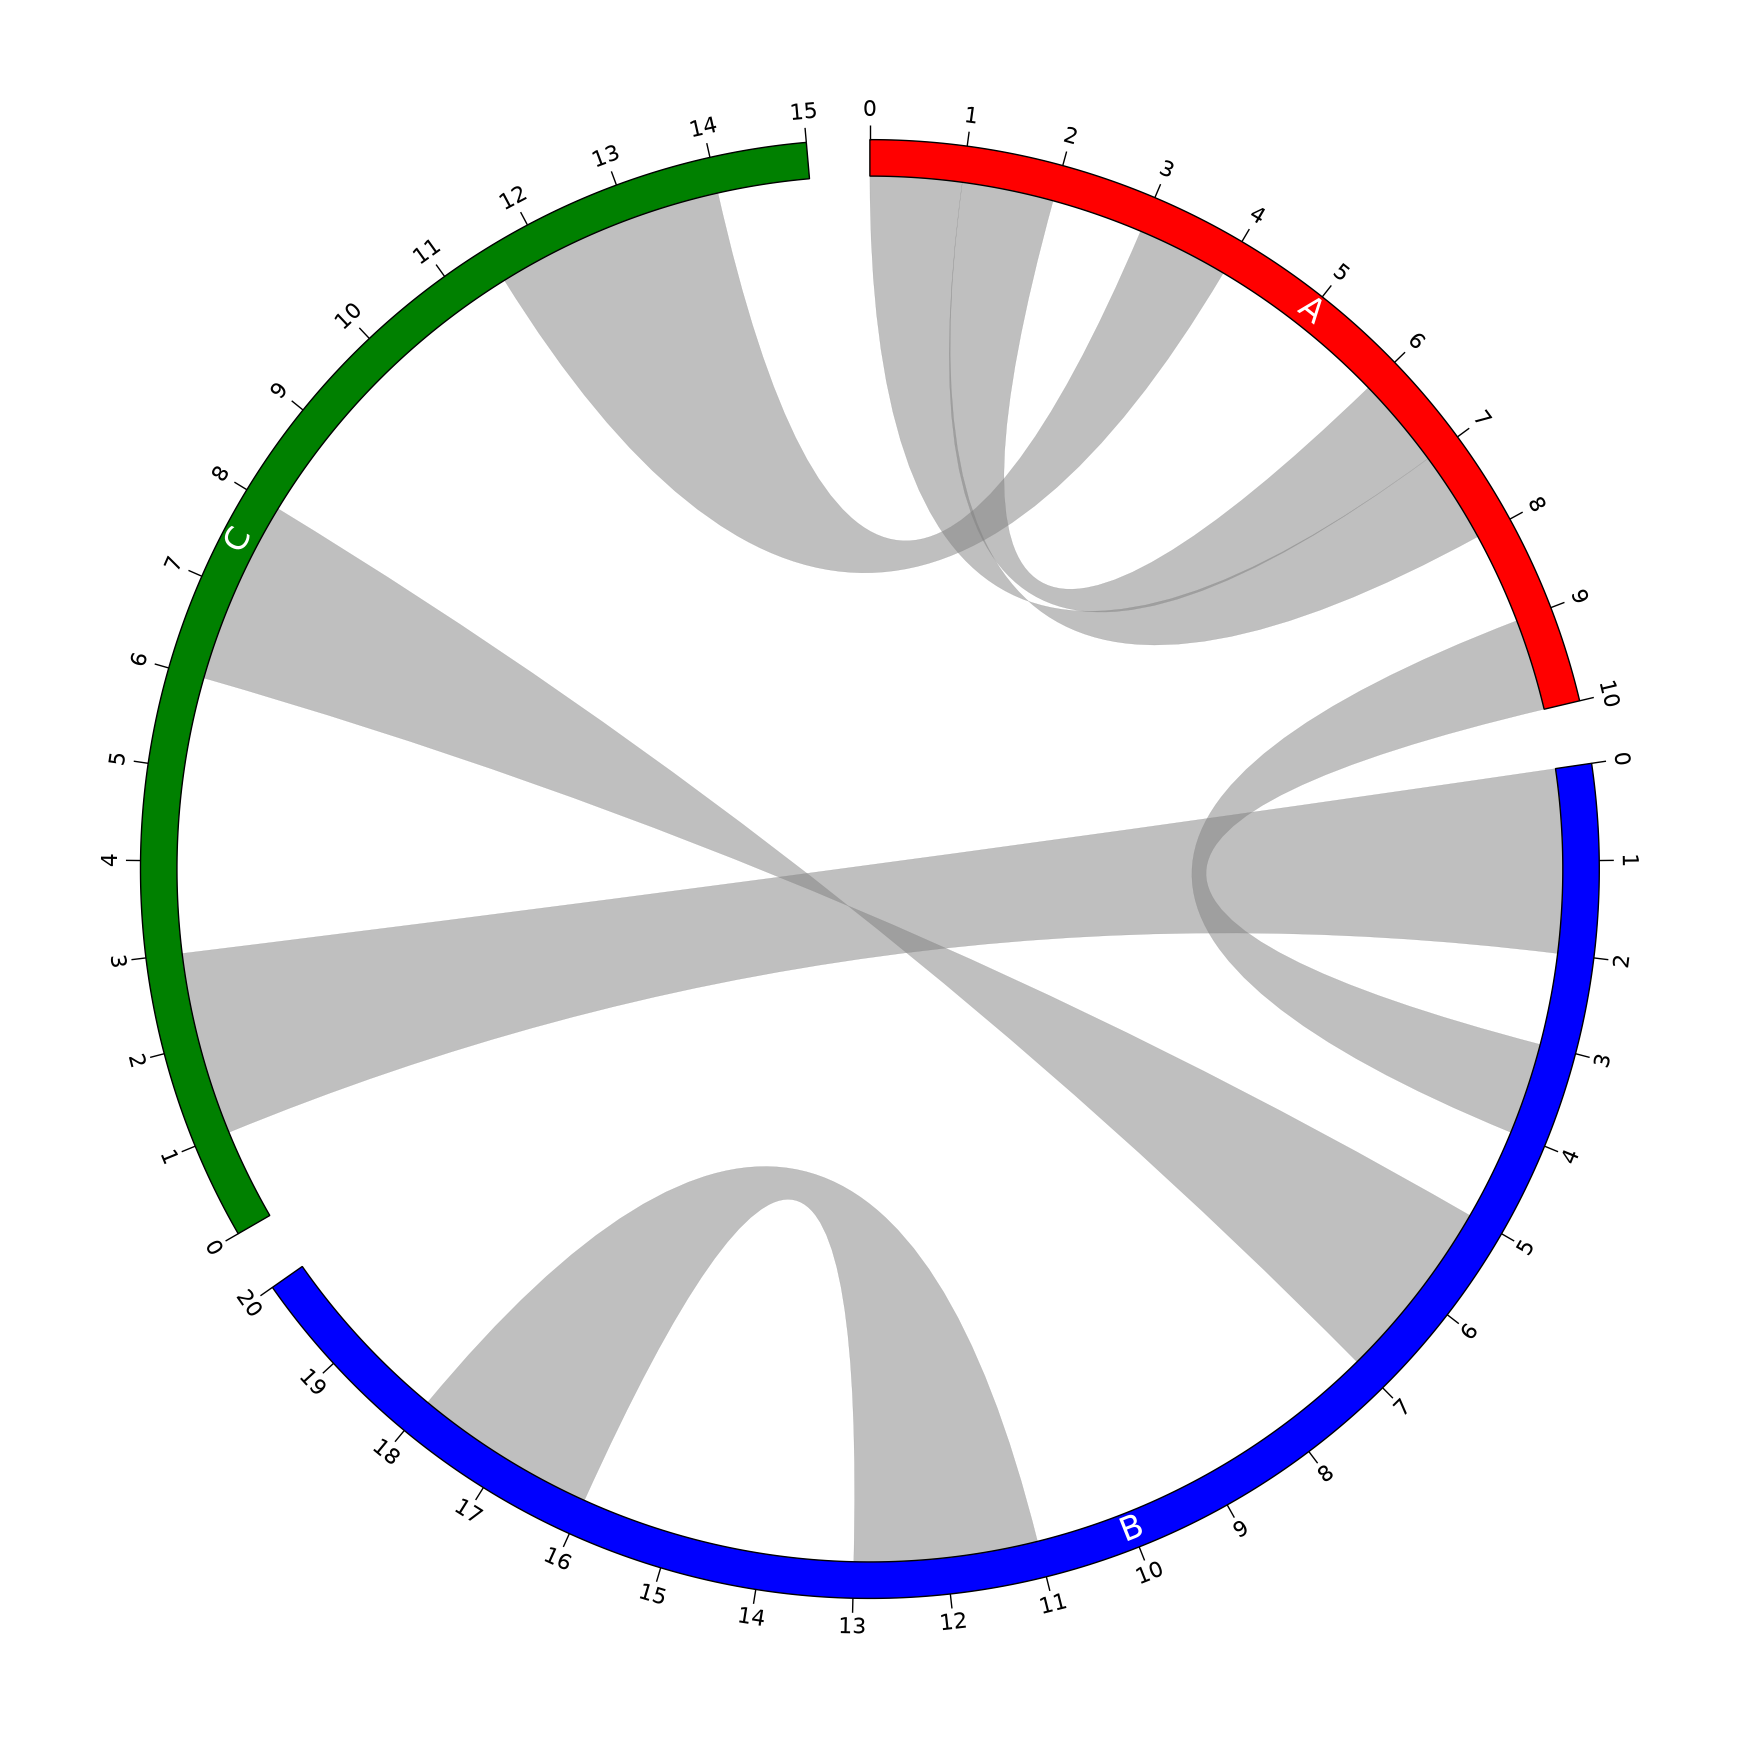

In [7]:
from pycirclize import Circos

sectors = {"A": 10, "B": 20, "C": 15}
name2color = {"A": "red", "B": "blue", "C": "green"}
circos = Circos(sectors, space=5)
for sector in circos.sectors:
    track = sector.add_track((95, 100))
    track.axis(fc=name2color[sector.name])
    track.text(sector.name, color="white", size=12)
    track.xticks_by_interval(1)

# Plot links
circos.link(("A", 0, 1), ("A", 7, 8))
circos.link(("A", 1, 2), ("A", 7, 6))
circos.link(("A", 9, 10), ("B", 4, 3))
circos.link(("B", 5, 7), ("C", 6, 8))
circos.link(("B", 18, 16), ("B", 11, 13))
circos.link(("C", 1, 3), ("B", 2, 0))
circos.link(("C", 11.5, 14), ("A", 4, 3))

fig = circos.plotfig()

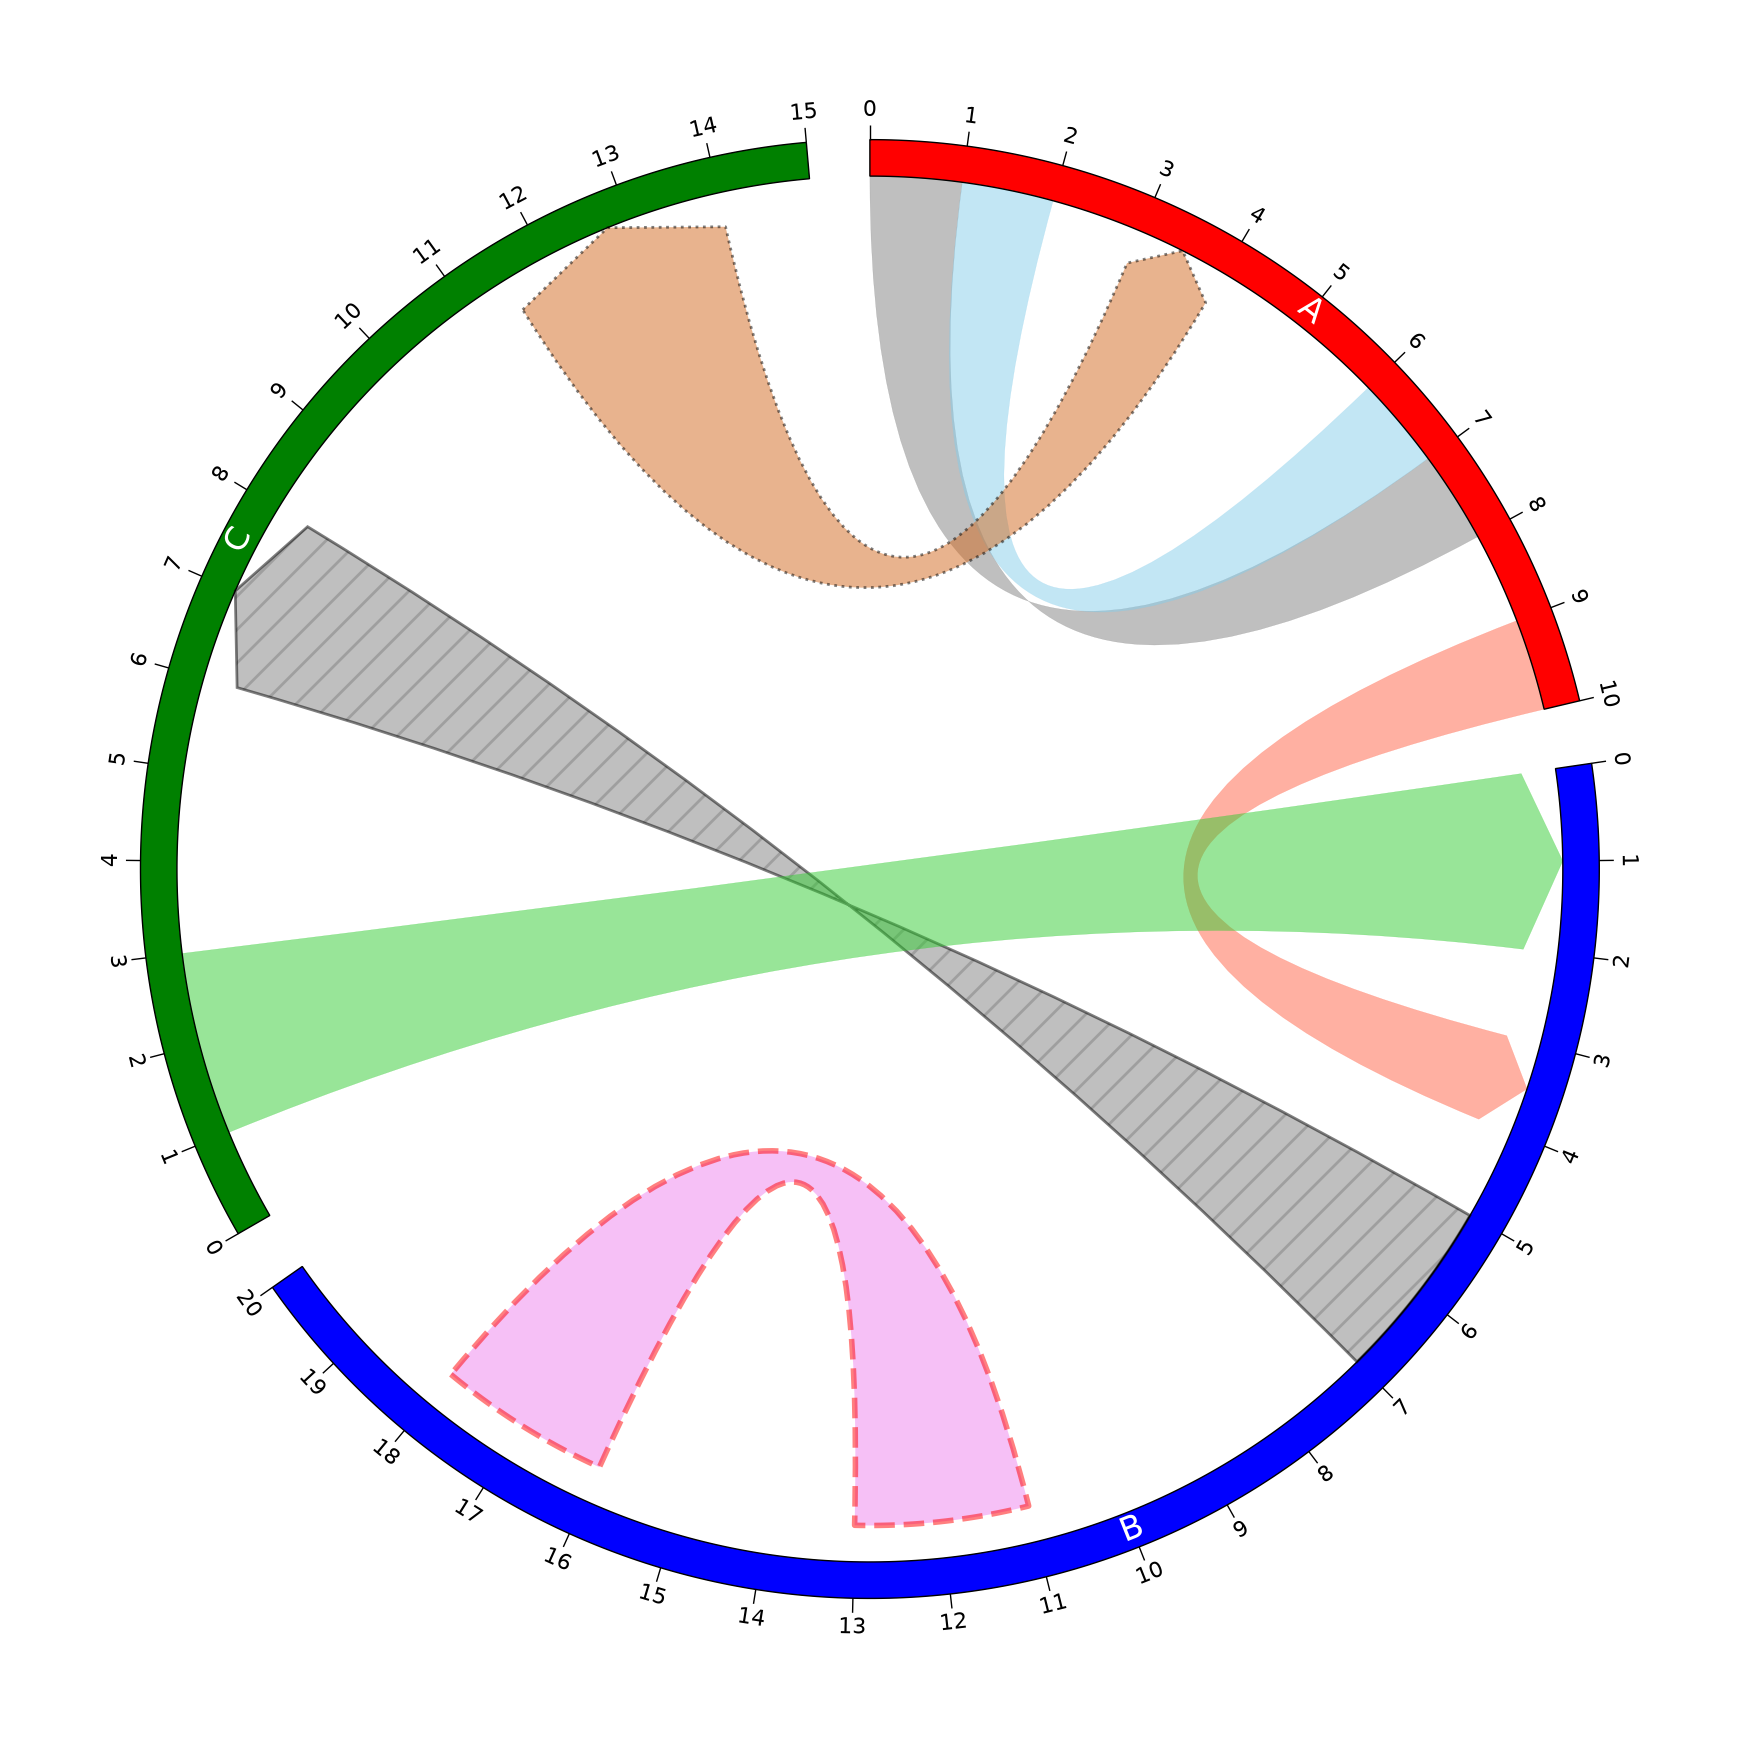

In [8]:
from pycirclize import Circos

sectors = {"A": 10, "B": 20, "C": 15}
name2color = {"A": "red", "B": "blue", "C": "green"}
circos = Circos(sectors, space=5)
for sector in circos.sectors:
    track = sector.add_track((95, 100))
    track.axis(fc=name2color[sector.name])
    track.text(sector.name, color="white", size=12)
    track.xticks_by_interval(1)

# Plot links with various styles
circos.link(("A", 0, 1), ("A", 7, 8))
circos.link(("A", 1, 2), ("A", 7, 6), color="skyblue")
circos.link(("A", 9, 10), ("B", 4, 3), direction=1, color="tomato")
circos.link(("B", 5, 7), ("C", 6, 8), direction=1, ec="black", lw=1, hatch="//")
circos.link(("B", 18, 16), ("B", 11, 13), r1=90, r2=90, color="violet", ec="red", lw=2, ls="dashed")
circos.link(("C", 1, 3), ("B", 2, 0), direction=1, color="limegreen")
circos.link(("C", 11.5, 14), ("A", 4, 3), direction=2, color="chocolate", ec="black", lw=1, ls="dotted")

fig = circos.plotfig()

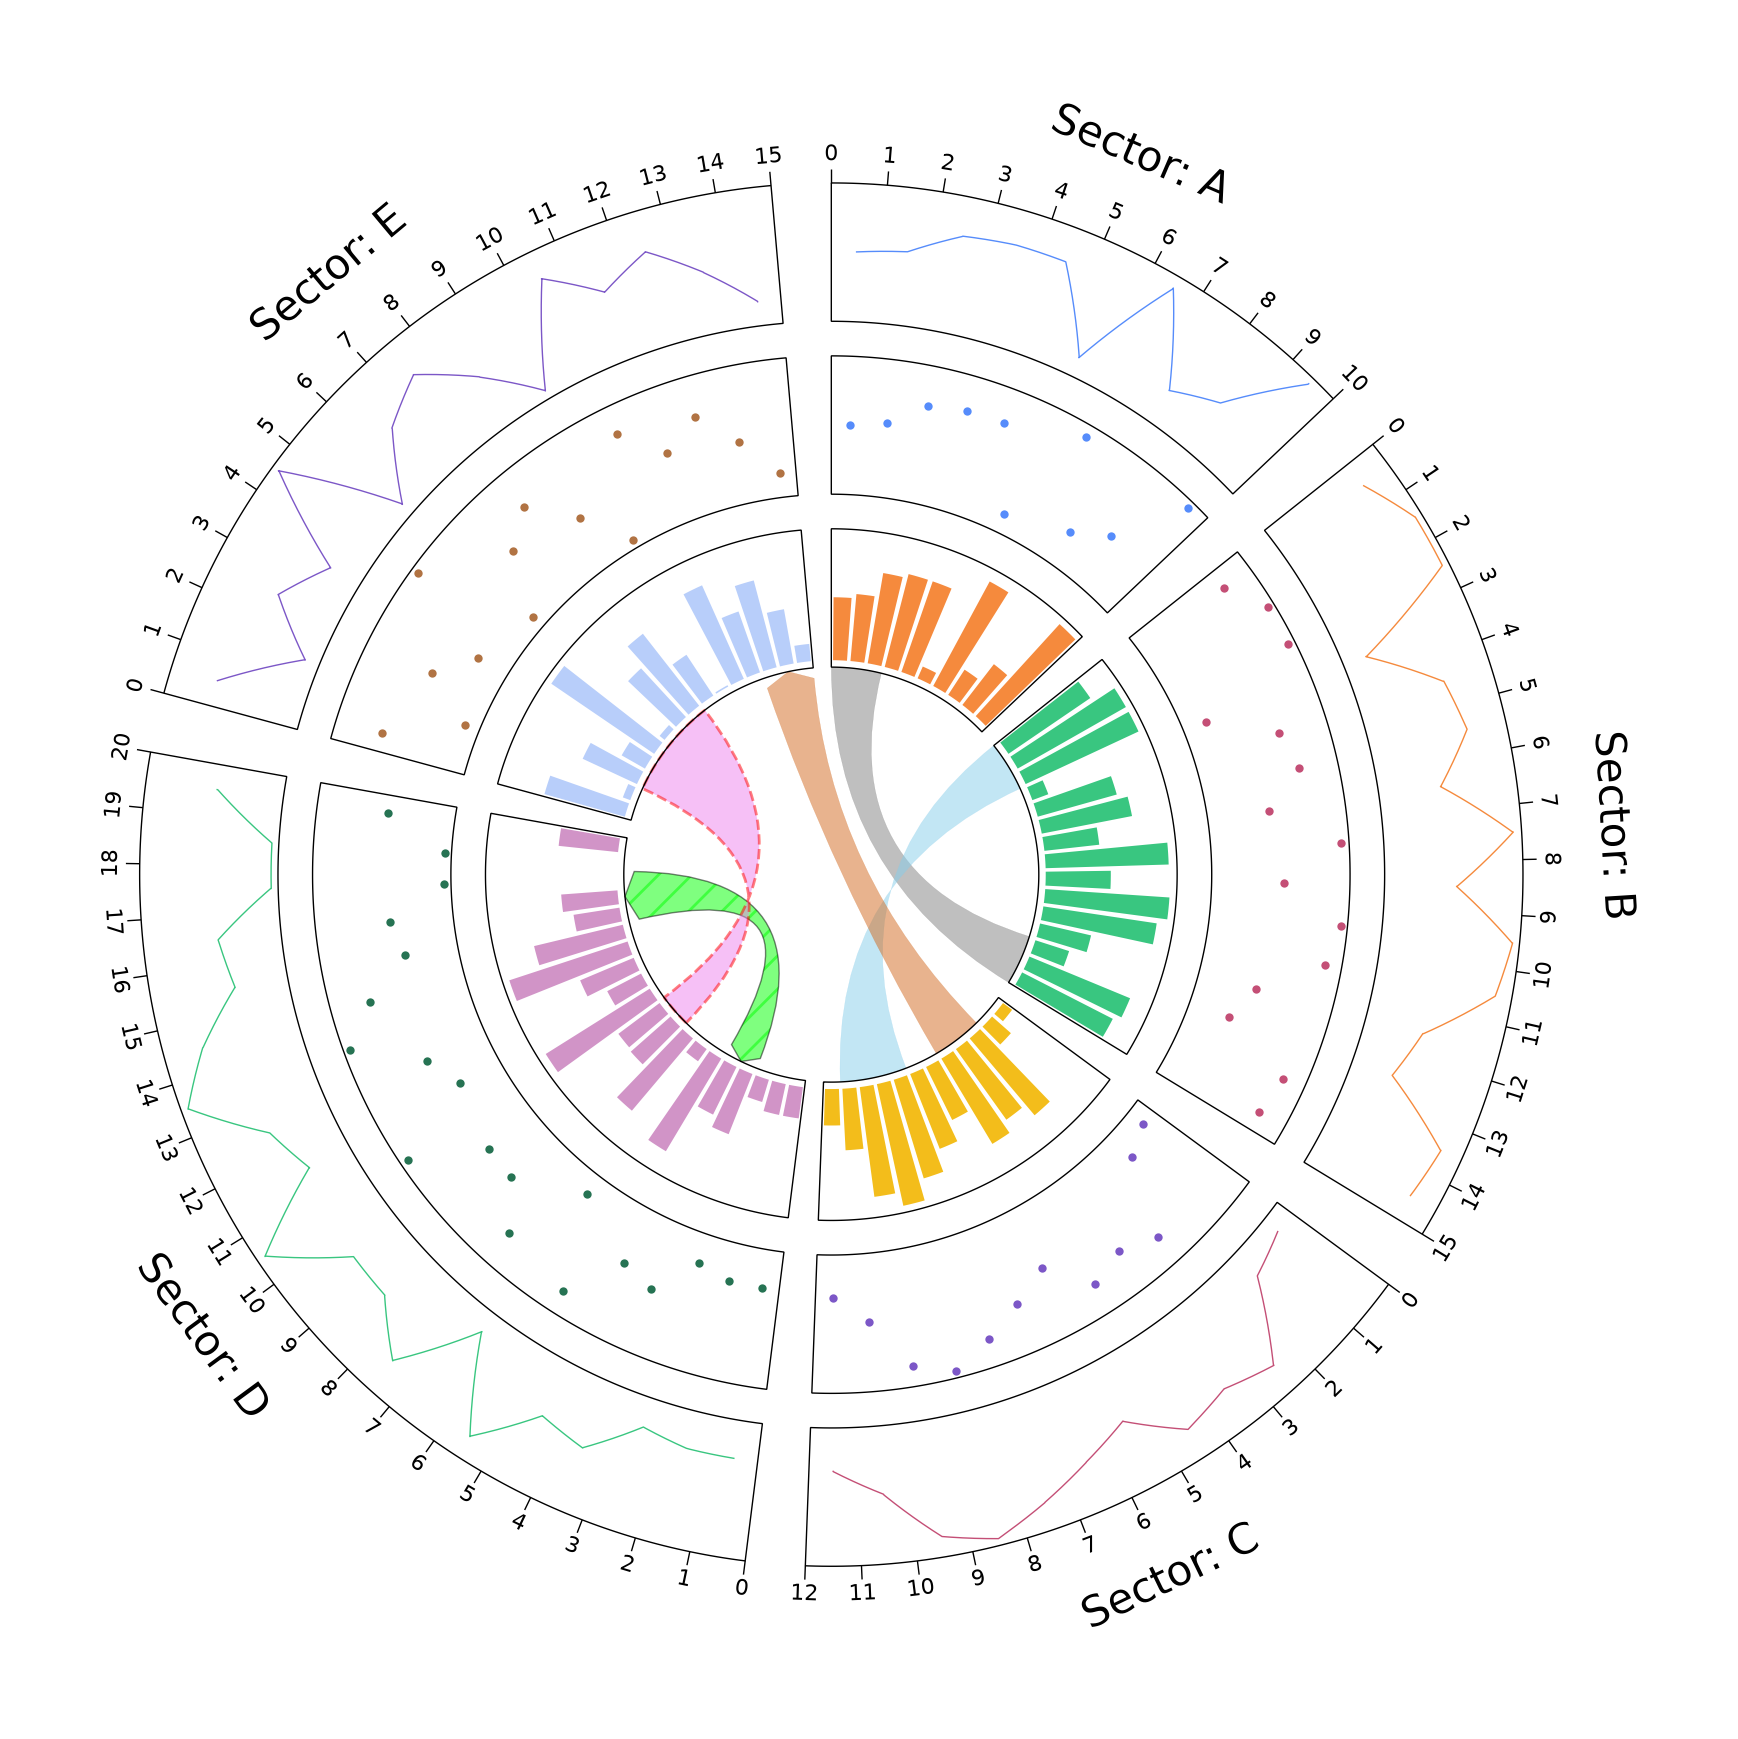

In [9]:
from pycirclize import Circos
import numpy as np
np.random.seed(0)

# Initialize Circos sectors
sectors = {"A": 10, "B": 15, "C": 12, "D": 20, "E": 15}
circos = Circos(sectors, space=5)

for sector in circos.sectors:
    # Plot sector name
    sector.text(f"Sector: {sector.name}", r=110, size=15)
    # Create x positions & randomized y values
    x = np.arange(sector.start, sector.end) + 0.5
    y = np.random.randint(0, 100, len(x))
    # Plot line track
    line_track = sector.add_track((80, 100), r_pad_ratio=0.1)
    line_track.xticks_by_interval(interval=1)
    line_track.axis()
    line_track.line(x, y)
    # Plot points track
    points_track = sector.add_track((55, 75), r_pad_ratio=0.1)
    points_track.axis()
    points_track.scatter(x, y)
    # Plot bar track
    bar_track = sector.add_track((30, 50), r_pad_ratio=0.1)
    bar_track.axis()
    bar_track.bar(x, y)

# Plot links
circos.link(("A", 0, 3), ("B", 15, 12))
circos.link(("B", 0, 3), ("C", 7, 11), color="skyblue")
circos.link(("C", 2, 5), ("E", 15, 12), color="chocolate", direction=1)
circos.link(("D", 3, 5), ("D", 18, 15), color="lime", ec="black", lw=0.5, hatch="//", direction=2)
circos.link(("D", 8, 10), ("E", 2, 8), color="violet", ec="red", lw=1.0, ls="dashed")

fig = circos.plotfig()